# Multi-Armed Bandits for Model Selection

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data.loader import load_ratings, load_movies
from src.data.splitter import split_temporal
from src.data.adapter import DataAdapter
from src.models.collaborative import ItemItemRecommender
from src.models.als import ALS
from src.models.content_based import ContentBasedRecommender
from src.models.epsilon_greedy import EpsilonGreedy
from src.models.thompson_sampling import ThompsonSampling

## 1. Load and Split Data

In [2]:
ratings = load_ratings()
movies = load_movies()

train_df, val_df, test_df = split_temporal(
    ratings,
    train_ratio=0.7,
    validation_ratio=0.15,
    test_ratio=0.15,
)

# Merge train + val for final model training
train_val_df = pd.concat([train_df, val_df], ignore_index=True)

print(f"Train+Val: {len(train_val_df):,} | Test: {len(test_df):,}")

Loaded 1000209 ratings from /Users/xandro/code/ucu/RECSYS/ucu-recsys/experiments/../data/ml-1m/ratings.dat
Loaded 3883 movies from /Users/xandro/code/ucu/RECSYS/ucu-recsys/experiments/../data/ml-1m/movies.dat
Train+Val: 850,199 | Test: 150,010


## 2. Train Candidate Models (Arms)

In [3]:
# --- Item-Item CF (cosine) ---
cf_model = ItemItemRecommender(method='cosine')
cf_model.fit(train_val_df)
print("CF (cosine) trained")

# --- ALS (implicit) ---
adapter = DataAdapter()
implicit_data = adapter.to_implicit(train_val_df, threshold=4.0)

als_model = ALS(factors=50, iterations=20, regularization=0.1, implicit=True, random_state=42)
als_model.fit(implicit_data)
print("ALS trained")

# --- Content-Based (jaccard) ---
cb_model = ContentBasedRecommender(similarity_method='jaccard')
cb_model.fit(movies)
# CB also needs a user-history pivot table for recommend()
train_val_pivot = train_val_df.pivot(
    index='user_id', columns='item_id', values='rating'
).fillna(0)
print("CB (jaccard) trained")

CF (cosine) trained


Numba is using threading layer workqueue - consider TBB
found 1 potential runtime problems - see https://boi.st/lkpy-perf


ALS trained
CB (jaccard) trained


## 3. Unified Recommend Wrappers

The three models have different `recommend()` signatures. We wrap them so
every arm returns a plain `set` of recommended item ids.

In [4]:
K = 10  # top-k for recommendations

def recommend_cf(user_id):
    """CF returns a DataFrame with an item_id column."""
    recs = cf_model.recommend(user_id, top_k=K)
    if recs.empty:
        return set()
    return set(recs['item_id'].values)

def recommend_als(user_id):
    """ALS returns a list of item ids."""
    return set(als_model.recommend(user_id, k=K))

def recommend_cb(user_id):
    """CB needs the user-history pivot table."""
    recs = cb_model.recommend(user_id, train_val_pivot, top_k=K)
    if recs.empty:
        return set()
    return set(recs['item_id'].values)

arm_fns = [recommend_cf, recommend_als, recommend_cb]
arm_names = ['CF (cosine)', 'ALS', 'CB (jaccard)']
n_arms = len(arm_fns)

print(f"Arms: {arm_names}")

Arms: ['CF (cosine)', 'ALS', 'CB (jaccard)']


## 4. Prepare Test Stream

Sort test interactions by timestamp to simulate online user arrivals.
Only keep positive interactions (rating >= 4) so reward=1 is meaningful.

In [5]:
test_positive = (
    test_df[test_df['rating'] >= 4]
    .sort_values('timestamp')
    .reset_index(drop=True)
)

print(f"Test stream: {len(test_positive):,} positive interactions")
test_positive.head()

Test stream: 77,830 positive interactions


,user_id,item_id,rating,timestamp
0,6039,2208,4,956706182
1,6039,1086,4,956706182
2,6039,2206,4,956706182
3,6039,942,4,956706201
4,6039,906,4,956706201


## 5. Run Bandit Simulation

For each test interaction `(user, item)`:
1. Bandit selects an arm (model).
2. That model produces top-k recommendations for the user.
3. Reward = 1 if the true item is in the top-k, else 0.
4. Bandit updates its beliefs.

Also run static policy that always picks the best offline arm (CF cosine,
which is the strongest similarity-based model from prior experiments).

In [6]:
SEED = 42
EPSILON = 0.1

# Initialise bandits
eg_bandit = EpsilonGreedy(n_arms=n_arms, epsilon=EPSILON, seed=SEED)
ts_bandit = ThompsonSampling(n_arms=n_arms, seed=SEED)

# Static policy always picks arm 0 (CF cosine)
STATIC_ARM = 0

# Storage
eg_rewards, ts_rewards, static_rewards = [], [], []
eg_arms_chosen, ts_arms_chosen = [], []

n_steps = len(test_positive)
log_every = n_steps // 10

for step, row in enumerate(test_positive.itertuples(index=False)):
    user_id = row.user_id
    true_item = row.item_id

    # --- Epsilon-Greedy ---
    eg_arm = eg_bandit.select_arm()
    eg_recs = arm_fns[eg_arm](user_id)
    eg_reward = 1.0 if true_item in eg_recs else 0.0
    eg_bandit.update(eg_arm, eg_reward)
    eg_rewards.append(eg_reward)
    eg_arms_chosen.append(eg_arm)

    # --- Thompson Sampling ---
    ts_arm = ts_bandit.select_arm()
    ts_recs = arm_fns[ts_arm](user_id)
    ts_reward = 1.0 if true_item in ts_recs else 0.0
    ts_bandit.update(ts_arm, ts_reward)
    ts_rewards.append(ts_reward)
    ts_arms_chosen.append(ts_arm)

    # --- Static Policy ---
    static_recs = arm_fns[STATIC_ARM](user_id)
    static_reward = 1.0 if true_item in static_recs else 0.0
    static_rewards.append(static_reward)

    if log_every > 0 and (step + 1) % log_every == 0:
        pct = 100 * (step + 1) / n_steps
        print(f"Step {step+1:,}/{n_steps:,} ({pct:.0f}%)  "
              f"EG cum={sum(eg_rewards):.0f}  "
              f"TS cum={sum(ts_rewards):.0f}  "
              f"Static cum={sum(static_rewards):.0f}")

print("\nSimulation complete.")

Step 7,783/77,830 (10%)  EG cum=457  TS cum=463  Static cum=485
Step 15,566/77,830 (20%)  EG cum=899  TS cum=919  Static cum=946
Step 23,349/77,830 (30%)  EG cum=1382  TS cum=1425  Static cum=1454
Step 31,132/77,830 (40%)  EG cum=1845  TS cum=1915  Static cum=1944
Step 38,915/77,830 (50%)  EG cum=2337  TS cum=2425  Static cum=2455
Step 46,698/77,830 (60%)  EG cum=2781  TS cum=2892  Static cum=2919
Step 54,481/77,830 (70%)  EG cum=3253  TS cum=3389  Static cum=3419
Step 62,264/77,830 (80%)  EG cum=3690  TS cum=3848  Static cum=3877
Step 70,047/77,830 (90%)  EG cum=4062  TS cum=4241  Static cum=4270
Step 77,830/77,830 (100%)  EG cum=4469  TS cum=4657  Static cum=4689

Simulation complete.


## 6. Results

In [7]:
eg_cum = np.cumsum(eg_rewards)
ts_cum = np.cumsum(ts_rewards)
static_cum = np.cumsum(static_rewards)

print(f"Total rewards  —  EG: {eg_cum[-1]:.0f}  |  TS: {ts_cum[-1]:.0f}  |  Static: {static_cum[-1]:.0f}")
print(f"Hit rate       —  EG: {eg_cum[-1]/n_steps:.4f}  |  TS: {ts_cum[-1]/n_steps:.4f}  |  Static: {static_cum[-1]/n_steps:.4f}")

Total rewards  —  EG: 4469  |  TS: 4657  |  Static: 4689
Hit rate       —  EG: 0.0574  |  TS: 0.0598  |  Static: 0.0602


### 6.1 Cumulative Reward

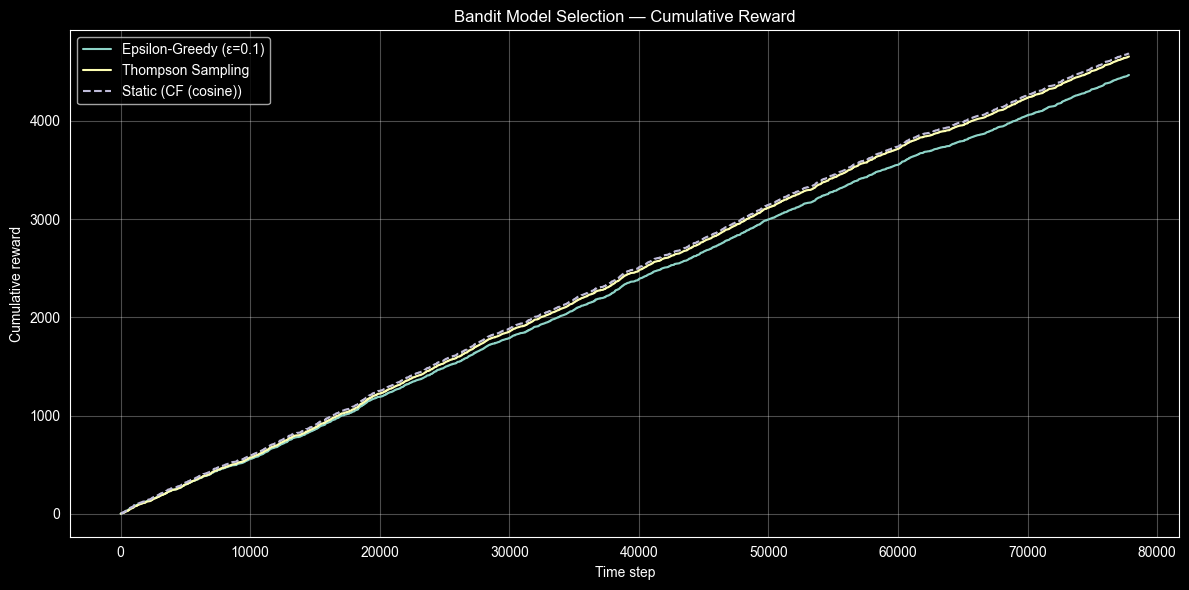

In [8]:
steps = np.arange(1, n_steps + 1)

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(steps, eg_cum, label=f'Epsilon-Greedy (ε={EPSILON})', linewidth=1.5)
ax.plot(steps, ts_cum, label='Thompson Sampling', linewidth=1.5)
ax.plot(steps, static_cum, label=f'Static ({arm_names[STATIC_ARM]})', linewidth=1.5, linestyle='--')
ax.set_xlabel('Time step')
ax.set_ylabel('Cumulative reward')
ax.set_title('Bandit Model Selection — Cumulative Reward')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../artifacts/bandits_cumulative_reward.png', dpi=150)
plt.show()

### 6.2 Cumulative Regret

Regret is measured relative to an oracle that always picks the arm yielding the highest reward for each interaction (best hindsight per-step).

Explanation for self:
1. Compute per-step oracle reward (best arm in hindsight)
2. We already have the rewards from each arm for the static policy (arm 0).
3. We need per-step rewards for *all* arms to build the oracle.
4. Recompute from the test stream.


Computing per-arm rewards for oracle...
  7,783/77,830
  15,566/77,830
  23,349/77,830
  31,132/77,830
  38,915/77,830
  46,698/77,830
  54,481/77,830
  62,264/77,830
  70,047/77,830
  77,830/77,830


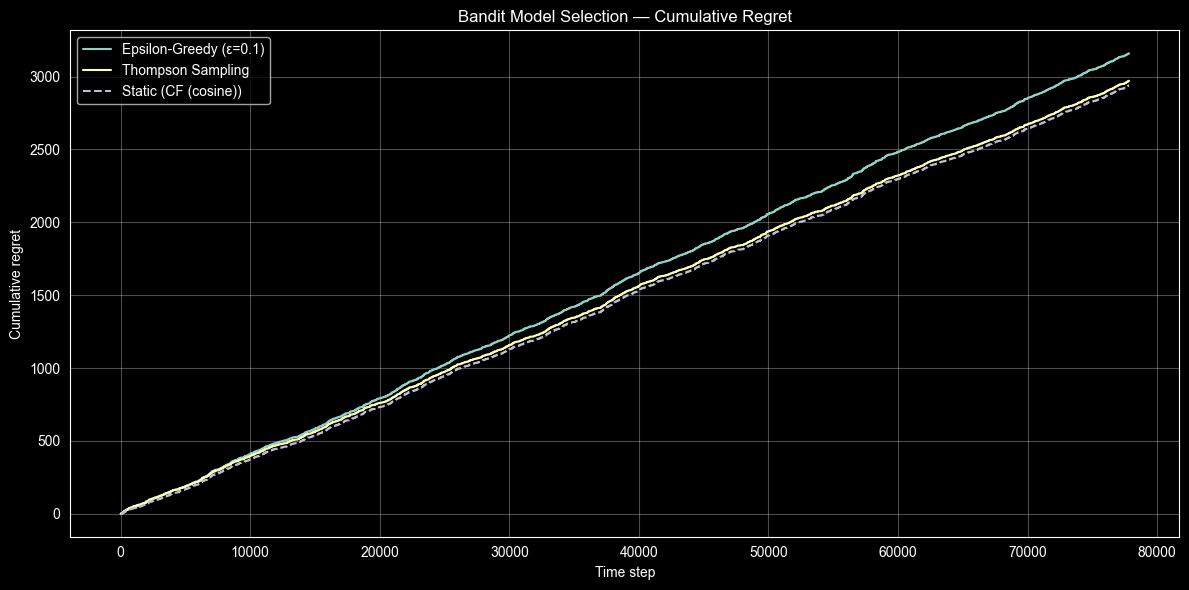

In [9]:
print("Computing per-arm rewards for oracle...")
arm_reward_matrix = np.zeros((n_steps, n_arms))

for step, row in enumerate(test_positive.itertuples(index=False)):
    user_id = row.user_id
    true_item = row.item_id
    for a in range(n_arms):
        recs = arm_fns[a](user_id)
        arm_reward_matrix[step, a] = 1.0 if true_item in recs else 0.0
    if log_every > 0 and (step + 1) % log_every == 0:
        print(f"  {step+1:,}/{n_steps:,}")

oracle_rewards = arm_reward_matrix.max(axis=1)
oracle_cum = np.cumsum(oracle_rewards)

eg_regret = np.cumsum(oracle_rewards - eg_rewards)
ts_regret = np.cumsum(oracle_rewards - ts_rewards)
static_regret = np.cumsum(oracle_rewards - static_rewards)

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(steps, eg_regret, label=f'Epsilon-Greedy (ε={EPSILON})', linewidth=1.5)
ax.plot(steps, ts_regret, label='Thompson Sampling', linewidth=1.5)
ax.plot(steps, static_regret, label=f'Static ({arm_names[STATIC_ARM]})', linewidth=1.5, linestyle='--')
ax.set_xlabel('Time step')
ax.set_ylabel('Cumulative regret')
ax.set_title('Bandit Model Selection — Cumulative Regret')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../artifacts/bandits_cumulative_regret.png', dpi=150)
plt.show()

### 6.3 Arm Selection Distribution

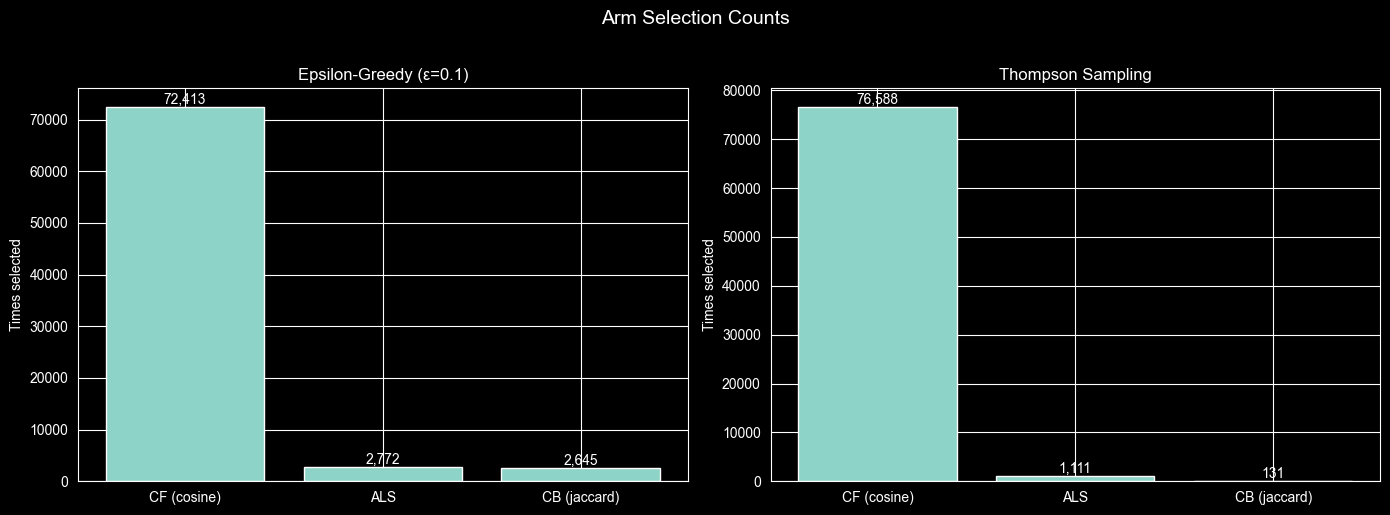

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, choices, title in [
    (axes[0], eg_arms_chosen, f'Epsilon-Greedy (ε={EPSILON})'),
    (axes[1], ts_arms_chosen, 'Thompson Sampling'),
]:
    counts = [choices.count(a) for a in range(n_arms)]
    bars = ax.bar(arm_names, counts)
    ax.set_ylabel('Times selected')
    ax.set_title(title)
    for bar, c in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                f'{c:,}', ha='center', va='bottom', fontsize=10)

plt.suptitle('Arm Selection Counts', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../artifacts/bandits_arm_selection.png', dpi=150)
plt.show()

### 6.4 Arm Selection Over Time

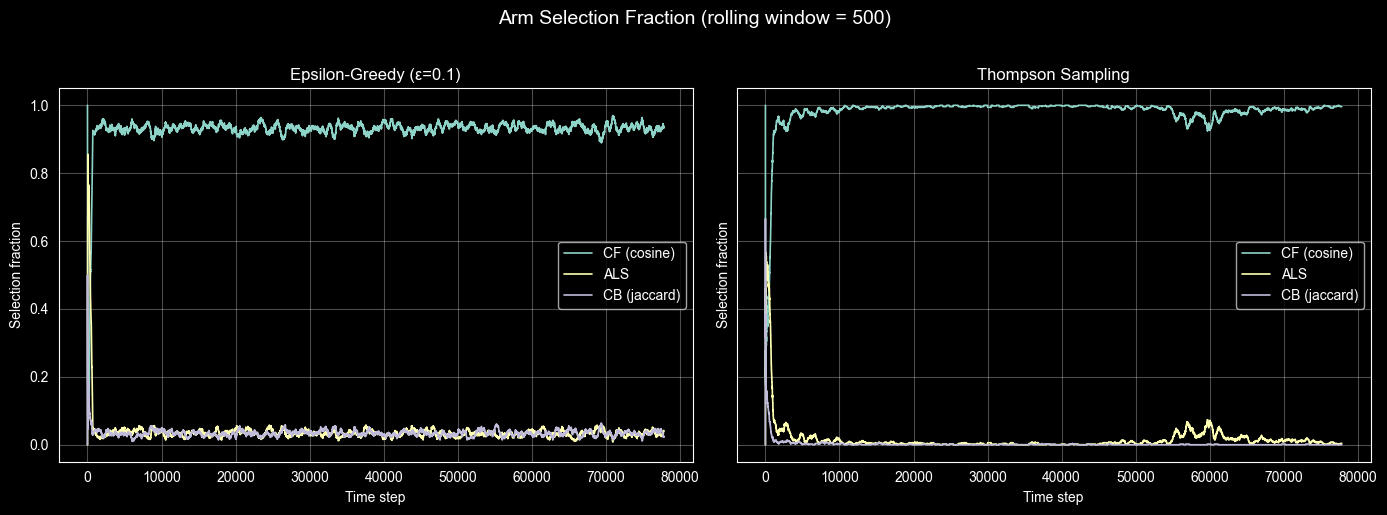

In [11]:
# Rolling fraction of times each arm was chosen (window = 500 steps).
window = 500

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, choices, title in [
    (axes[0], eg_arms_chosen, f'Epsilon-Greedy (ε={EPSILON})'),
    (axes[1], ts_arms_chosen, 'Thompson Sampling'),
]:
    for a in range(n_arms):
        indicator = pd.Series([1.0 if c == a else 0.0 for c in choices])
        rolling = indicator.rolling(window, min_periods=1).mean()
        ax.plot(rolling, label=arm_names[a], linewidth=1.2)
    ax.set_xlabel('Time step')
    ax.set_ylabel('Selection fraction')
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle(f'Arm Selection Fraction (rolling window = {window})', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../artifacts/bandits_arm_fraction.png', dpi=150)
plt.show()

### 6.5 Per-Arm Reward Rates

In [12]:
# Compute hit rate per arm across the entire test stream
per_arm_hits = arm_reward_matrix.sum(axis=0)
per_arm_rate = per_arm_hits / n_steps

arm_stats = pd.DataFrame({
    'Arm': arm_names,
    'Hits': per_arm_hits.astype(int),
    'Hit Rate': per_arm_rate,
    'EG Pulls': [eg_bandit.counts[a] for a in range(n_arms)],
    'EG Avg Reward': [
        eg_bandit.rewards[a] / eg_bandit.counts[a] if eg_bandit.counts[a] > 0 else 0
        for a in range(n_arms)
    ],
    'TS Pulls': [ts_bandit.counts[a] for a in range(n_arms)],
    'TS Alpha': [ts_bandit.alpha[a] for a in range(n_arms)],
    'TS Beta': [ts_bandit.beta[a] for a in range(n_arms)],
})

arm_stats

,Arm,Hits,Hit Rate,EG Pulls,EG Avg Reward,TS Pulls,TS Alpha,TS Beta
0,CF (cosine),4689,0.060247,72413,0.059796,76588,4611.0,71979.0
1,ALS,3588,0.046100,2772,0.043290,1111,48.0,1065.0
2,CB (jaccard),463,0.005949,2645,0.007183,131,1.0,132.0


## 7. Summary

| Strategy | Approach | Adaptation |
|----------|----------|------------|
| **Static Policy** | Always picks one model | None — flat cumulative reward line |
| **Epsilon-Greedy** | Exploits best-so-far, explores with probability ε | Converges to best arm but keeps exploring |
| **Thompson Sampling** | Samples from posterior, explores naturally | Converges faster — exploration decreases as confidence grows |

Thompson Sampling typically achieves lower regret than epsilon-greedy because
its exploration is *informed* by uncertainty, while epsilon-greedy explores
uniformly at random regardless of what it has learned.